# Pipeline Run Visualization

This notebook visualizes the full hierarchical pipeline run, including:
- Timeline/Gantt chart showing system execution flow
- Performance metrics and timing information
- Pipeline flow diagram
- Summary statistics

In [7]:
import json
import os
import glob
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from IPython.display import display, HTML, Markdown

In [8]:
def find_most_recent_pipeline_run():
    """
    Find the most recent pipeline_run JSON file.
    Returns: (pipeline_run_path, pipeline_run_id)
    """
    from pathlib import Path

    cwd = Path.cwd().resolve()

    # Try likely locations first, then walk up parents for project markers.
    candidate_logs_dirs = [
        cwd / "pipeline_logs",
        cwd.parent / "pipeline_logs",
    ]

    for parent in cwd.parents:
        if (parent / "src").exists() and (parent / "config").exists():
            candidate_logs_dirs.append(parent / "pipeline_logs")

    # Respect an explicit override when provided.
    env_logs_dir = os.environ.get("PIPELINE_LOGS_DIR")
    if env_logs_dir:
        candidate_logs_dirs.append(Path(env_logs_dir).expanduser().resolve())

    # De-duplicate while preserving order.
    seen = set()
    unique_logs_dirs = []
    for path in candidate_logs_dirs:
        path_str = str(path)
        if path_str not in seen:
            unique_logs_dirs.append(path)
            seen.add(path_str)

    pipeline_runs = []
    searched_patterns = []

    for logs_dir in unique_logs_dirs:
        pattern = str(logs_dir / "pipeline_run_*.json")
        searched_patterns.append(pattern)
        pipeline_runs.extend(glob.glob(pattern))

    if not pipeline_runs:
        searched_text = "\n".join(f"  - {p}" for p in searched_patterns)
        raise FileNotFoundError(
            "No pipeline_run files found. Please run the hierarchical system notebook first "
            "or set PIPELINE_LOGS_DIR to the correct logs directory.\n"
            f"Searched patterns:\n{searched_text}"
        )

    # Sort by modification time (most recent first)
    pipeline_runs.sort(key=os.path.getmtime, reverse=True)

    most_recent_path = pipeline_runs[0]

    # Extract pipeline_run_id from filename
    filename = os.path.basename(most_recent_path)
    pipeline_run_id = filename.replace("pipeline_run_", "").replace(".json", "")

    return most_recent_path, pipeline_run_id

# Load the most recent pipeline run
print("Finding most recent pipeline run...")
try:
    pipeline_run_path, pipeline_run_id = find_most_recent_pipeline_run()
    print(f"Found pipeline run: {pipeline_run_id}")
    print(f"  Path: {pipeline_run_path}")
    
    # Load pipeline run data
    with open(pipeline_run_path, 'r') as f:
        pipeline_run = json.load(f)
    
    print(f"\nPipeline Run ID: {pipeline_run['pipeline_run_id']}")
    print(f"Start Time: {pipeline_run['start_time']}")
    print(f"End Time: {pipeline_run.get('end_time', 'N/A')}")
    print(f"Total Duration: {pipeline_run.get('total_duration_seconds', 0):.2f} seconds")
    loop_info = pipeline_run.get('system2_system3_loop', {})
    final_info = pipeline_run.get('final_outcome', {})

    print(f"Total Iterations: {loop_info.get('total_iterations', len(loop_info.get('iterations', []) or []))}")
    print(f"Final Status: {final_info.get('status', 'N/A')}")
    
except FileNotFoundError as e:
    print(f"Error: {e}")
    raise
except Exception as e:
    print(f"Unexpected error: {e}")
    raise

Finding most recent pipeline run...
Found pipeline run: 2026031106
  Path: /orcd/pool/004/tphage/SG_march/Sys3Dev/pipeline_logs/pipeline_run_2026031106.json

Pipeline Run ID: 2026031106
Start Time: 2026-03-11T10:13:08.897339Z
End Time: 2026-03-11T11:11:34.837245Z
Total Duration: 3505.94 seconds
Total Iterations: 2
Final Status: manufacturable


## Timeline Visualization (Gantt Chart)

Visualize the execution timeline showing System 1, System 2 iterations, and System 3 executions:

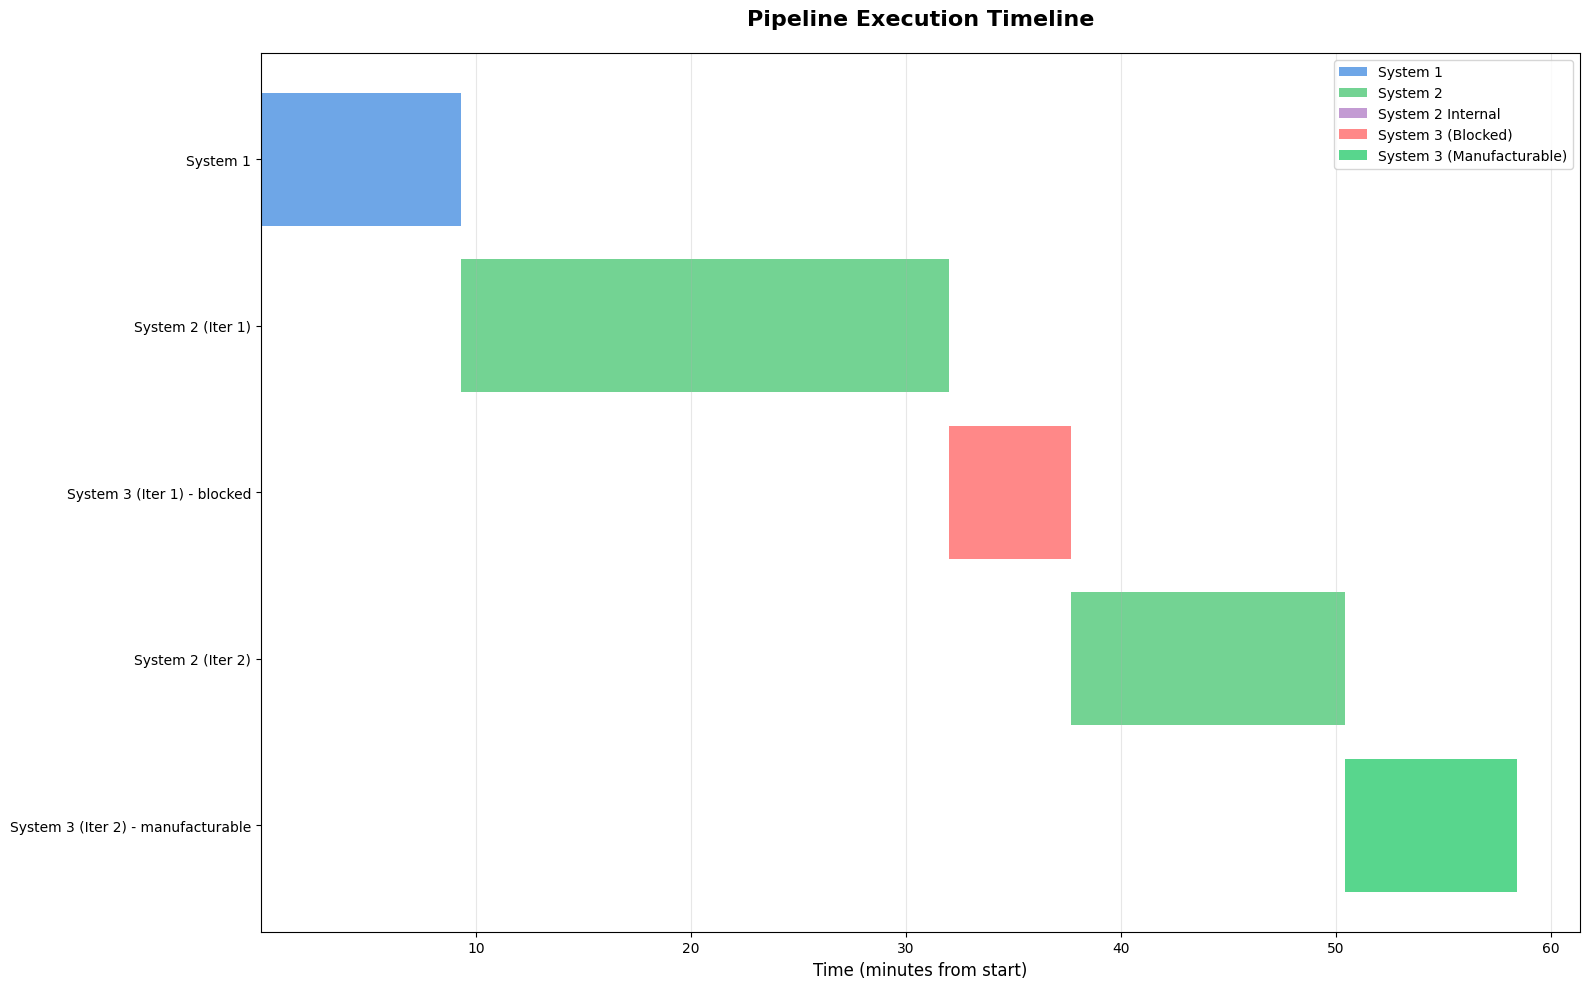

In [9]:
def create_timeline_gantt(pipeline_run):
    """
    Create a Gantt chart showing the execution timeline.
    """
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Parse start time
    start_time = datetime.fromisoformat(pipeline_run['start_time'].replace('Z', '+00:00'))
    
    # Colors for different systems
    colors = {
        'system1': '#4A90E2',
        'system2': '#50C878',
        'system3': '#FF6B6B',
        'system2_internal': '#9B59B6'
    }
    
    y_pos = 0
    y_labels = []
    
    # Plot System 1
    if pipeline_run['system1']['start_time']:
        s1_start = datetime.fromisoformat(pipeline_run['system1']['start_time'].replace('Z', '+00:00'))
        s1_end = datetime.fromisoformat(pipeline_run['system1']['end_time'].replace('Z', '+00:00'))
        s1_duration = (s1_end - s1_start).total_seconds() / 60  # Convert to minutes
        
        ax.barh(y_pos, s1_duration, left=(s1_start - start_time).total_seconds() / 60, 
                color=colors['system1'], alpha=0.8, label='System 1')
        y_labels.append('System 1')
        y_pos += 1
    
    # Plot System 2 → System 3 iterations
    iterations = pipeline_run.get('system2_system3_loop', {}).get('iterations', []) or []
    for iter_data in iterations:
        iter_num = iter_data['iteration']
        
        # System 2
        s2_start = datetime.fromisoformat(iter_data['system2']['start_time'].replace('Z', '+00:00'))
        s2_end = datetime.fromisoformat(iter_data['system2']['end_time'].replace('Z', '+00:00'))
        s2_duration = (s2_end - s2_start).total_seconds() / 60  # Convert to minutes
        
        ax.barh(y_pos, s2_duration, left=(s2_start - start_time).total_seconds() / 60,
                color=colors['system2'], alpha=0.8, label=f'System 2 (Iter {iter_num})' if iter_num == 1 else '')
        y_labels.append(f'System 2 (Iter {iter_num})')
        
        # Plot internal iterations within System 2
        internal_y = y_pos + 0.3
        for internal_iter in iter_data['system2'].get('internal_iterations', []):
            int_start = datetime.fromisoformat(internal_iter['start_time'].replace('Z', '+00:00'))
            int_end = datetime.fromisoformat(internal_iter['end_time'].replace('Z', '+00:00'))
            int_duration = (int_end - int_start).total_seconds() / 60  # Convert to minutes
            
            ax.barh(internal_y, int_duration, left=(int_start - start_time).total_seconds() / 60,
                    height=0.2, color=colors['system2_internal'], alpha=0.6)
            internal_y += 0.25
        
        y_pos += 1
        
        # System 3
        s3_start = datetime.fromisoformat(iter_data['system3']['start_time'].replace('Z', '+00:00'))
        s3_end = datetime.fromisoformat(iter_data['system3']['end_time'].replace('Z', '+00:00'))
        s3_duration = (s3_end - s3_start).total_seconds() / 60  # Convert to minutes
        
        status_color = colors['system3']
        if iter_data['system3']['status'] == 'manufacturable':
            status_color = '#2ECC71'  # Green for success
        
        ax.barh(y_pos, s3_duration, left=(s3_start - start_time).total_seconds() / 60,
                color=status_color, alpha=0.8, label=f'System 3 (Iter {iter_num})' if iter_num == 1 else '')
        y_labels.append(f"System 3 (Iter {iter_num}) - {iter_data['system3']['status']}")
        y_pos += 1
    
    # Formatting
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)
    ax.set_xlabel('Time (minutes from start)', fontsize=12)
    ax.set_title('Pipeline Execution Timeline', fontsize=16, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3)
    
    # Invert y-axis so System 1 is at the top and System 3 at the bottom
    ax.invert_yaxis()
    
    # Create custom legend with all categories
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors['system1'], alpha=0.8, label='System 1'),
        Patch(facecolor=colors['system2'], alpha=0.8, label='System 2'),
        Patch(facecolor=colors['system2_internal'], alpha=0.6, label='System 2 Internal'),
        Patch(facecolor=colors['system3'], alpha=0.8, label='System 3 (Blocked)'),
        Patch(facecolor='#2ECC71', alpha=0.8, label='System 3 (Manufacturable)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    return fig

# Create timeline visualization
fig = create_timeline_gantt(pipeline_run)
plt.show()

## Performance Metrics

In [10]:
# Calculate and display performance metrics
total_duration = pipeline_run.get('total_duration_seconds', 0) or 0
s1_duration = pipeline_run.get('system1', {}).get('duration_seconds', 0) or 0

s2_durations = []
s3_durations = []
internal_iter_durations = []

for iter_data in (pipeline_run.get('system2_system3_loop', {}).get('iterations', []) or []):
    s2_durations.append(iter_data['system2']['duration_seconds'])
    s3_durations.append(iter_data['system3']['duration_seconds'])
    
    for internal_iter in iter_data['system2'].get('internal_iterations', []):
        internal_iter_durations.append(internal_iter['duration_seconds'])

metrics_html = f"""
<div style='font-family: Arial, sans-serif; padding: 20px; background: #f5f5f5; border-radius: 10px;'>
    <h2 style='color: #333; margin-top: 0;'>Performance Metrics</h2>
    
    <div style='display: grid; grid-template-columns: repeat(2, 1fr); gap: 20px;'>
        <div style='background: white; padding: 15px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
            <h3 style='color: #4A90E2; margin-top: 0;'>Total Execution</h3>
            <p style='font-size: 24px; font-weight: bold; color: #333;'>{total_duration:.2f} seconds</p>
            <p style='color: #666;'>({total_duration/60:.2f} minutes)</p>
        </div>
        
        <div style='background: white; padding: 15px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
            <h3 style='color: #4A90E2; margin-top: 0;'>System 1</h3>
            <p style='font-size: 24px; font-weight: bold; color: #333;'>{s1_duration:.2f} seconds</p>
            <p style='color: #666;'>({(s1_duration/total_duration*100) if total_duration else 0:.1f}% of total)</p>
        </div>
        
        <div style='background: white; padding: 15px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
            <h3 style='color: #50C878; margin-top: 0;'>System 2 (Average)</h3>
            <p style='font-size: 24px; font-weight: bold; color: #333;'>{np.mean(s2_durations) if s2_durations else 0:.2f} seconds</p>
            <p style='color: #666;'>Total: {sum(s2_durations):.2f}s over {len(s2_durations)} iteration(s)</p>
        </div>
        
        <div style='background: white; padding: 15px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
            <h3 style='color: #FF6B6B; margin-top: 0;'>System 3 (Average)</h3>
            <p style='font-size: 24px; font-weight: bold; color: #333;'>{np.mean(s3_durations) if s3_durations else 0:.2f} seconds</p>
            <p style='color: #666;'>Total: {sum(s3_durations):.2f}s over {len(s3_durations)} iteration(s)</p>
        </div>
    </div>
    
    {f"<div style='background: white; padding: 15px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); margin-top: 20px;'>"
     f"<h3 style='color: #9B59B6; margin-top: 0;'>System 2 Internal Iterations (Average)</h3>"
     f"<p style='font-size: 24px; font-weight: bold; color: #333;'>{np.mean(internal_iter_durations) if internal_iter_durations else 0:.2f} seconds</p>"
     f"<p style='color: #666;'>Total: {len(internal_iter_durations)} internal iteration(s)</p>"
     f"</div>" if internal_iter_durations else ""}
</div>
"""

display(HTML(metrics_html))

## Pipeline Flow Diagram

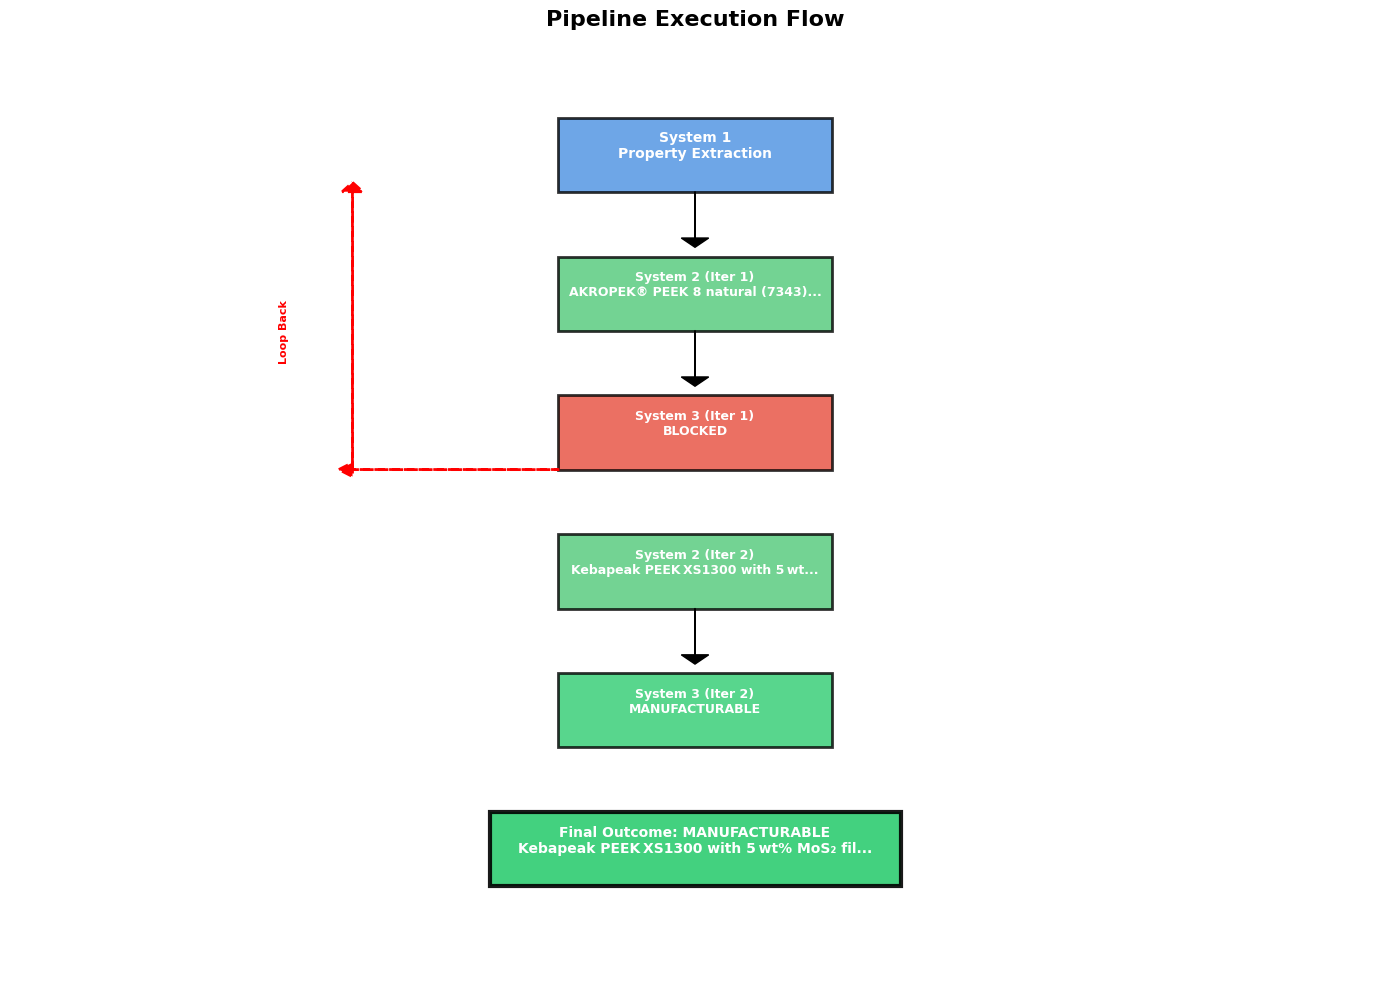

In [11]:
def create_flow_diagram(pipeline_run):
    """Create a flow diagram showing the pipeline execution flow."""

    def _safe_upper(val, default="N/A"):
        if val is None or val == "":
            return default
        return str(val).upper()

    def _safe_trunc(val, n, default="N/A"):
        if val is None or val == "":
            return default
        s = str(val)
        return (s[:n] + "...") if len(s) > n else s

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Colors
    s1_color = '#4A90E2'
    s2_color = '#50C878'
    success_color = '#2ECC71'
    blocked_color = '#E74C3C'
    neutral_color = '#95A5A6'

    y_start = 9
    x_center = 5

    # System 1
    s1_box = Rectangle((x_center - 1, y_start - 0.5), 2, 0.8,
                       facecolor=s1_color, alpha=0.8, edgecolor='black', linewidth=2)
    ax.add_patch(s1_box)
    ax.text(x_center, y_start, 'System 1\nProperty Extraction',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

    # Arrow down
    ax.arrow(x_center, y_start - 0.5, 0, -0.5, head_width=0.2, head_length=0.1,
             fc='black', ec='black')

    y_pos = y_start - 1.5

    # System 2 → System 3 loop
    loop_info = pipeline_run.get('system2_system3_loop', {})
    iterations = loop_info.get('iterations', []) or []

    for i, iter_data in enumerate(iterations):
        iter_num = iter_data.get('iteration', i + 1)

        # System 2 box
        s2_box = Rectangle((x_center - 1, y_pos - 0.5), 2, 0.8,
                           facecolor=s2_color, alpha=0.8, edgecolor='black', linewidth=2)
        ax.add_patch(s2_box)
        candidate = _safe_trunc(iter_data.get('system2', {}).get('candidate'), 30)
        ax.text(x_center, y_pos, f'System 2 (Iter {iter_num})\n{candidate}',
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

        # Arrow to System 3
        ax.arrow(x_center, y_pos - 0.5, 0, -0.5, head_width=0.2, head_length=0.1,
                 fc='black', ec='black')

        y_pos -= 1.5

        # System 3 box
        s3_status = iter_data.get('system3', {}).get('status')
        s3_box_color = success_color if s3_status == 'manufacturable' else blocked_color
        s3_box = Rectangle((x_center - 1, y_pos - 0.5), 2, 0.8,
                           facecolor=s3_box_color, alpha=0.8, edgecolor='black', linewidth=2)
        ax.add_patch(s3_box)
        ax.text(x_center, y_pos, f'System 3 (Iter {iter_num})\n{_safe_upper(s3_status, "UNKNOWN")}',
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

        # Loop-back arrows
        if s3_status == 'blocked' and i < len(iterations) - 1:
            ax.arrow(x_center - 1, y_pos - 0.5, -1.5, 0, head_width=0.15, head_length=0.1,
                     fc='red', ec='red', linestyle='--', linewidth=2)
            ax.arrow(x_center - 2.5, y_pos - 0.5, 0, 3, head_width=0.15, head_length=0.1,
                     fc='red', ec='red', linestyle='--', linewidth=2)
            ax.text(x_center - 3, y_pos + 1, 'Loop Back', rotation=90,
                    ha='center', va='center', fontsize=8, color='red', fontweight='bold')

        y_pos -= 1.5

    if not iterations:
        # Display a placeholder when no iterations have been executed
        no_iter_box = Rectangle((x_center - 2, y_pos - 0.5), 4, 0.8,
                               facecolor=neutral_color, alpha=0.8, edgecolor='black', linewidth=2)
        ax.add_patch(no_iter_box)
        ax.text(x_center, y_pos, 'No System 2 / System 3 iterations',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        y_pos -= 1.5

    # Final outcome
    final_info = pipeline_run.get('final_outcome', {})
    final_status = final_info.get('status')
    final_color = success_color if final_status == 'manufacturable' else blocked_color
    final_box = Rectangle((x_center - 1.5, y_pos - 0.5), 3, 0.8,
                          facecolor=final_color, alpha=0.9, edgecolor='black', linewidth=3)
    ax.add_patch(final_box)
    final_candidate = _safe_trunc(final_info.get('final_candidate'), 40, default="N/A")
    ax.text(x_center, y_pos, f'Final Outcome: {_safe_upper(final_status, "UNKNOWN")}\n{final_candidate}',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

    ax.set_title('Pipeline Execution Flow', fontsize=16, fontweight='bold', pad=20)

    plt.tight_layout()
    return fig

# Create flow diagram
fig = create_flow_diagram(pipeline_run)
plt.show()

## Summary Statistics

In [12]:
# Display summary statistics
summary_data = {
    'Metric': [
        'Total Execution Time',
        'System 1 Duration',
        'Total System 2 Iterations',
        'Total System 3 Iterations',
        'Candidates Proposed',
        'Candidates Rejected',
        'Final Status',
        'Final Candidate'
    ],
    'Value': [
        f"{pipeline_run.get('total_duration_seconds', 0):.2f} seconds ({pipeline_run.get('total_duration_seconds', 0)/60:.2f} min)",
        f"{pipeline_run.get('system1', {}).get('duration_seconds', 0):.2f} seconds",
        pipeline_run.get('system2_system3_loop', {}).get('total_iterations', 0),
        pipeline_run.get('system2_system3_loop', {}).get('total_iterations', 0),
        pipeline_run.get('system2_system3_loop', {}).get('total_iterations', 0) + pipeline_run.get('final_outcome', {}).get('total_rejected_candidates', 0),
        pipeline_run.get('final_outcome', {}).get('total_rejected_candidates', 0),
        pipeline_run.get('final_outcome', {}).get('status', 'N/A'),
        pipeline_run.get('final_outcome', {}).get('final_candidate', 'N/A')
    ]
}

df_summary = pd.DataFrame(summary_data)
display(df_summary.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4A90E2'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('padding', '10px')]}
]))

,Metric,Value
0,Total Execution Time,3505.94 seconds (58.43 min)
1,System 1 Duration,558.29 seconds
2,Total System 2 Iterations,2
3,Total System 3 Iterations,2
4,Candidates Proposed,5
5,Candidates Rejected,3
6,Final Status,manufacturable
7,Final Candidate,Kebapeak PEEK XS1300 with 5 wt% MoS₂ filler
